In [1]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00a 0:00:01


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
os.mkdir('./yolov8')

In [4]:
model = YOLO("yolov8l.pt")


In [5]:
model.model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [6]:
#Class Label from the weapon class map 'Automatic Rifle': 0, 'Bazooka': 1, 
#'Grenade Launcher': 2, 'Handgun': 3, 'Knife': 4, 'Shotgun': 5, 'SMG': 6, 
#'Sniper': 7, 'Sword': 8



In [7]:
# create yaml file

yolo_format=dict(path="/kaggle/input/weapon-detection-test/weapon_detection",
                 train="/kaggle/input/weapon-detection-test/weapon_detection/train",
                 val="/kaggle/input/weapon-detection-test/weapon_detection/val",
                 nc=9,
                 names={0:'Automatic Rifle', 1:'Bazooka',3: 'Handgun', 4:'Knife', 2:'Grenade Launcher', 5:'Shotgun', 6:'SMG', 7:'Sniper', 8:'Sword'})

In [8]:
import yaml

# write the data to the .yaml file
with open('/kaggle/working/yolov8/data.yaml', 'w') as f:
    yaml.dump(yolo_format, f)

In [9]:
# read the content in .yaml file
with open('/kaggle/working/yolov8/data.yaml', 'r') as f:
    yaml_weap = yaml.safe_load(f)
    display(yaml_weap)

{'names': {0: 'Automatic Rifle',
  1: 'Bazooka',
  2: 'Grenade Launcher',
  3: 'Handgun',
  4: 'Knife',
  5: 'Shotgun',
  6: 'SMG',
  7: 'Sniper',
  8: 'Sword'},
 'nc': 9,
 'path': '/kaggle/input/weapon-detection-test/weapon_detection',
 'train': '/kaggle/input/weapon-detection-test/weapon_detection/train',
 'val': '/kaggle/input/weapon-detection-test/weapon_detection/val'}

In [10]:
import wandb
wandb.init(mode='disabled')

In [11]:
model.train(data='/kaggle/working/yolov8/data.yaml', epochs=50, batch=24)


Ultralytics 8.4.19 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

2026-03-01 19:39:41,051	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-01 19:39:41,521	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=9

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d6a281b0b80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [12]:
# validation

metrics = model.val()

Ultralytics 8.4.19 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 113 layers, 43,613,547 parameters, 0 gradients, 164.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 281.3±255.5 MB/s, size: 497.0 KB)
val: Scanning /kaggle/input/weapon-detection-test/weapon_detection/val/labels... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 901.1it/s 0.2s2s
WARNING ⚠️ val: Cache directory /kaggle/input/weapon-detection-test/weapon_detection/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.3it/s 3.9s0.4ss
                   all        143        219      0.506       0.48      0.507      0.432
       Automatic Rifle        106        162      0.785      0.927        0.9      0.733
               Bazooka          4          6          0          0     0.0663     0.0434
      Grenade Launcher         19         24      0.767       

In [13]:
print(f"Mean Average Precision @.5:.95 : {metrics.box.map}")    
print(f"Mean Average Precision @ .50   : {metrics.box.map50}") 
print(f"Mean Average Precision @ .70   : {metrics.box.map75}")

Mean Average Precision @.5:.95 : 0.43210972882366333
Mean Average Precision @ .50   : 0.5066187303135121
Mean Average Precision @ .70   : 0.47183297316994394


In [14]:
import torch
test_imgs_dir = '/kaggle/input/weapon-detection-test/test/test'
with torch.no_grad():
    results=model.predict(source=test_imgs_dir,conf=0.50,iou=0.75)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/8 /kaggle/input/weapon-detection-test/test/test/army.jpg: 448x640 (no detections), 41.2ms
image 2/8 /kaggle/input/weapon-detection-test/test/test/terrorists.jpg: 384x640 1 Automatic Rifle, 42.8ms
image 3/8 /kaggle/input/weapon-detection-test/test/test/terrorists2.jpg: 384x640 1 Automatic Rifle, 18.6ms
image 4/8 /kaggle/input/weapon-detection-test/test/test/weapons.jpg: 448x640 1 Automatic Rifle, 18.9ms
image 5/8 /kaggle/input/weapon-detection-tes

In [15]:
!mkdir "/kaggle/working/predictions"
prediction_dir="/kaggle/working/predictions"

In [16]:
len(results)

114

In [17]:
test_img_list=[]
for result in results:
    if len(result.boxes.xyxy):
        name=result.path.split("/")[-1].split(".")[0]
        boxes=result.boxes.xyxy.cpu().numpy()
        scores=result.boxes.conf.cpu().numpy()
        
        test_img_list.append(name)
        
        label_file_path=os.path.join(prediction_dir,name+".txt")
        with open(label_file_path,"w+") as f:
            for score,box in zip(scores,boxes):
                text=f"{score:0.4f} "+" ".join(box.astype(str))
                f.write(text)
                f.write("\n")

In [18]:
import cv2
# vis. predictions 
def show_bbox(img,boxes,scores,axis,color=(0,255,0)):
    boxes=boxes.astype(int)
    scores=scores
    img=img.copy()
    for i,box in enumerate(boxes):
        score=f"{scores[i]:.4f}"
        cv2.rectangle(img,(box[0],box[1]),(box[2],box[3]),color,2)
        y=box[1]-10 if box[1]-10>10 else box[1]+10
        cv2.putText(img,score,(box[0],y),cv2.FONT_HERSHEY_SIMPLEX,0.5,color,2)
    
    axis.imshow(img)
    axis.axis("off")

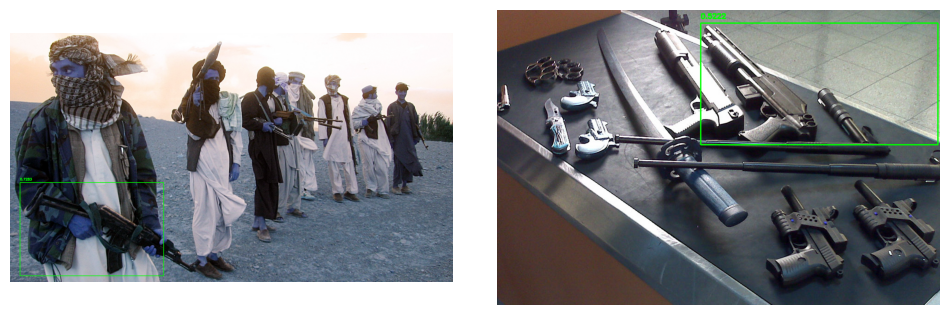

In [19]:
fig,axes=plt.subplots(1,2,figsize=(12,12))
plt.subplots_adjust(wspace=0.1,hspace=0.1)
ax=axes.flatten()

imgs_name=['terrorists2','weapons']

for i,img_name in enumerate(imgs_name):
    img_file_path=os.path.join(test_imgs_dir,img_name+".jpg")
    img=cv2.imread(img_file_path)
   # img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    
    label_file_path=os.path.join(prediction_dir,img_name+".txt")
    label=pd.read_csv(label_file_path,sep=" ",header=None).values
    scores=label[:,0]
    boxes=label[:,1:]
    show_bbox(img,boxes,scores,axis=ax[i])
    
plt.savefig("1.png")

In [20]:
# lets see distrbution of classes

df = pd.read_csv('/kaggle/input/weapon-detection-test/metadata.csv')
df

,imagefile,labelfile,target,train_id
0,Automatic Rifle_10.jpeg,Automatic Rifle_10.txt,0,1
1,Automatic Rifle_100.jpeg,Automatic Rifle_100.txt,0,1
2,Automatic Rifle_11.jpeg,Automatic Rifle_11.txt,0,1
3,Automatic Rifle_12.jpeg,Automatic Rifle_12.txt,0,1
4,Automatic Rifle_13.jpeg,Automatic Rifle_13.txt,0,0
...,...,...,...,...
709,Sword_95.jpeg,Sword_95.txt,8,1
710,Sword_96.jpeg,Sword_96.txt,8,0
711,Sword_97.jpeg,Sword_97.txt,8,1
712,Sword_98.jpeg,Sword_98.txt,8,1


In [21]:
df.target.value_counts()

target
7    89
8    89
2    88
6    87
5    78
0    74
4    72
3    70
1    67
Name: count, dtype: int64

In [22]:
df.train_id.value_counts()

train_id
1    571
0    143
Name: count, dtype: int64

In [23]:
f = df.groupby('train_id')['target']

In [24]:
f.value_counts()

train_id  target
0         2         18
          7         18
          8         18
          6         17
          5         16
          0         15
          3         14
          4         14
          1         13
1         7         71
          8         71
          2         70
          6         70
          5         62
          0         59
          4         58
          3         56
          1         54
Name: count, dtype: int64

In [25]:
# lets save cropped images for classification task
# no need for yolo, already have bboxes


In [26]:
import os
from PIL import Image, ImageDraw
import pandas as pd  # Assuming you're using pandas to read the annotations

def convert_yolo_to_bbox(image_path, label_path):
    # Load the image
    image = Image.open(image_path)
    img_width, img_height = image.size
    draw = ImageDraw.Draw(image)

    # Read the label file
    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line_parts = line.strip().split()
        class_label = int(line_parts[0])
        
        # Extract YOLO format values
        x_center = float(line_parts[1]) * img_width
        y_center = float(line_parts[2]) * img_height
        box_width = float(line_parts[3]) * img_width
        box_height = float(line_parts[4]) * img_height

        # Convert to xmin, ymin, xmax, ymax
        xmin = int(x_center - box_width / 2)
        ymin = int(y_center - box_height / 2)
        xmax = int(x_center + box_width / 2)
        ymax = int(y_center + box_height / 2)

        # Validate bbox values
        if xmin < xmax and ymin < ymax:
            # Draw the bounding box
            draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)
        else:
            print(f"Invalid bbox: ({xmin}, {ymin}, {xmax}, {ymax}) for class {class_label}")

    # Save or show the image with bounding boxes
    output_path = "image_with_bboxes.jpg"
    image.save(output_path)
    image.show()

# Test with a single image
image_path = "/kaggle/input/weapon-detection-test/weapon_detection/train/images/Automatic Rifle_10.jpeg"
label_path = "/kaggle/input/weapon-detection-test/weapon_detection/train/labels/Automatic Rifle_10.txt"

convert_yolo_to_bbox(image_path, label_path)

/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmpl8vrgynv.PNG'


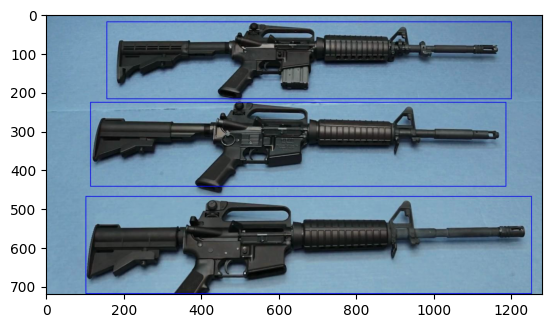

In [27]:
plt.imshow(cv2.imread(  '/kaggle/working/image_with_bboxes.jpg'))

- its work

In [28]:
import os
from PIL import Image

class_names = { 'Automatic Rifle':0,  'Bazooka':1,  'Grenade Launcher':2,  'Handgun':3,  'Knife':4,  'Shotgun':5, 'SMG':6, 'Sniper':7,  'Sword':8}

def convert_yolo_to_bbox_and_crop(image_dir, label_dir, output_dir, is_train=True):
    # Create output directory for train or val
    train_or_val = "train" if is_train else "val"
    output_class_dir = os.path.join(output_dir, train_or_val)
    os.makedirs(output_class_dir, exist_ok=True)

    # Iterate over all label files in the directory
    for label_filename in os.listdir(label_dir):
        if label_filename.endswith('.txt'):
            base_filename = os.path.splitext(label_filename)[0]  # Get the base name without extension
            image_filename = f"{base_filename}.jpg"  # Assuming images are in JPG format
            if not os.path.exists(os.path.join(image_dir, image_filename)):
                image_filename = f"{base_filename}.png"  # Check for PNG if JPG not found
            if not os.path.exists(os.path.join(image_dir, image_filename)):
                image_filename = f"{base_filename}.jpeg"  # Check for jpeg if JPG not found

            image_path = os.path.join(image_dir, image_filename)
            # Check if the corresponding image file exists
            if not os.path.exists(image_path):
                print(f"Image file not found for {label_filename}: {image_path}")
                continue  # Skip if there is no matching image

            # Load the image
            image = Image.open(image_path)
            img_width, img_height = image.size

            # Create class directories
            with open(os.path.join(label_dir, label_filename), 'r') as f:
                lines = f.readlines()
                print(100*'-')
                print(lines)
     
            
            for line in lines:
                line_parts = line.strip().split()
                class_label = int(line_parts[0])
                print(class_label)
                # Create class-specific folder
                class_folder = os.path.join(output_class_dir, str(class_label))
                os.makedirs(class_folder, exist_ok=True)
               
                # Extract YOLO format values
                x_center = float(line_parts[1]) * img_width
                y_center = float(line_parts[2]) * img_height
                box_width = float(line_parts[3]) * img_width
                box_height = float(line_parts[4]) * img_height

                # Convert to xmin, ymin, xmax, ymax
                xmin = int(x_center - box_width / 2)
                ymin = int(y_center - box_height / 2)
                xmax = int(x_center + box_width / 2)
                ymax = int(y_center + box_height / 2)

                # Validate bbox values
                if xmin < xmax and ymin < ymax:
                    # Crop the image
                    cropped_image = image.crop((xmin, ymin, xmax, ymax))

                    # Convert to RGB if the image is in RGBA or P mode
                    if cropped_image.mode in ('RGBA', 'P'):
                        cropped_image = cropped_image.convert('RGB')

                    # Save the cropped image
                    cropped_image_filename = f"{base_filename}_class_{class_label}.jpg"
                    cropped_image.save(os.path.join(class_folder, cropped_image_filename))
                else:
                    print(f"Invalid bbox: ({xmin}, {ymin}, {xmax}, {ymax}) for class {class_label}")

In [29]:
output_directory = "./cropped2"  # Change this to your desired output directory
image_path = "/kaggle/input/weapon-detection-test/weapon_detection/train/images"
label_path = "/kaggle/input/weapon-detection-test/weapon_detection/train/labels"

# Save cropped images for training
convert_yolo_to_bbox_and_crop(image_path, label_path, output_directory, is_train=True)


----------------------------------------------------------------------------------------------------
['2 0.450000 0.497503 0.830000 0.330836\n']
2
----------------------------------------------------------------------------------------------------
['0 0.508125 0.496111 0.640000 0.767778\n']
0
----------------------------------------------------------------------------------------------------
['0 0.572746 0.509107 0.811475 0.642987\n']
0
----------------------------------------------------------------------------------------------------
['0 0.234807 0.274590 0.362799 0.480328\n', '0 0.190608 0.781967 0.338858 0.403279\n', '0 0.496317 0.454918 0.272560 0.460656\n', '0 0.751842 0.267213 0.343462 0.416393\n', '0 0.749079 0.774590 0.374770 0.450820\n']
0
0
0
0
0
----------------------------------------------------------------------------------------------------
['5 0.486000 0.492800 0.918000 0.923200\n']
5
-------------------------------------------------------------------------------------

/opt/conda/lib/python3.10/site-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


0
----------------------------------------------------------------------------------------------------
['0 0.503918 0.485938 0.916928 0.828125\n']
0
----------------------------------------------------------------------------------------------------
['0 0.507000 0.505714 0.962000 0.954286\n']
0
----------------------------------------------------------------------------------------------------
['2 0.515833 0.566406 0.861667 0.664062\n']
2
----------------------------------------------------------------------------------------------------
['0 0.389160 0.794760 0.209961 0.368996\n', '0 0.240723 0.706878 0.188477 0.250000\n', '0 0.155273 0.590066 0.244141 0.236900\n', '0 0.134766 0.430677 0.220703 0.160480\n', '0 0.193848 0.278930 0.250977 0.145197\n', '0 0.311035 0.196507 0.223633 0.207424\n', '0 0.428223 0.170306 0.172852 0.240175\n', '0 0.602539 0.175764 0.154297 0.275109\n', '0 0.808105 0.400109 0.278320 0.201965\n', '0 0.840820 0.558406 0.238281 0.177948\n', '0 0.768555 0.684498 0.32

In [30]:
import shutil

shutil.copy(
    "runs/detect/train/weights/best.pt",
    "/kaggle/working/best.pt"
)

'/kaggle/working/best.pt'

- wrong annotations -_-